<a href="https://colab.research.google.com/github/novalrnv/machine_learning/blob/main/JS04/JS04-Tugas%20Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Tugas

###**1. Identifikasi variabel-variabel yang akan digunakan sebagai variabel bebas (fitur) dan variabel target (biaya medis personal).**

In [3]:
import pandas as pd

# Membaca dataset
df = pd.read_csv('/content/insurance.csv')

# Menampilkan 5 data pertama
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Membaca file insurance.csv dan menampilkan 5 data pertama untuk melihat isi dataset.

In [4]:
# Melihat ukuran dataset
print("Ukuran dataset:", df.shape)

# Melihat informasi dataset
df.info()

Ukuran dataset: (1338, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


Membaca file insurance.csv dan menampilkan 5 data pertama untuk melihat isi dataset.

In [5]:
# Menentukan variabel fitur (X) dan target (y)
X = df.drop('charges', axis=1)
y = df['charges']

print("Fitur (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

Fitur (X):
   age     sex     bmi  children smoker     region
0   19  female  27.900         0    yes  southwest
1   18    male  33.770         1     no  southeast
2   28    male  33.000         3     no  southeast
3   33    male  22.705         0     no  northwest
4   32    male  28.880         0     no  northwest

Target (y):
0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64


Memisahkan dataset menjadi fitur (X) yang digunakan untuk melakukan prediksi dan target (y) yaitu charges sebagai biaya medis personal.

###**Visualisasi** **Data**

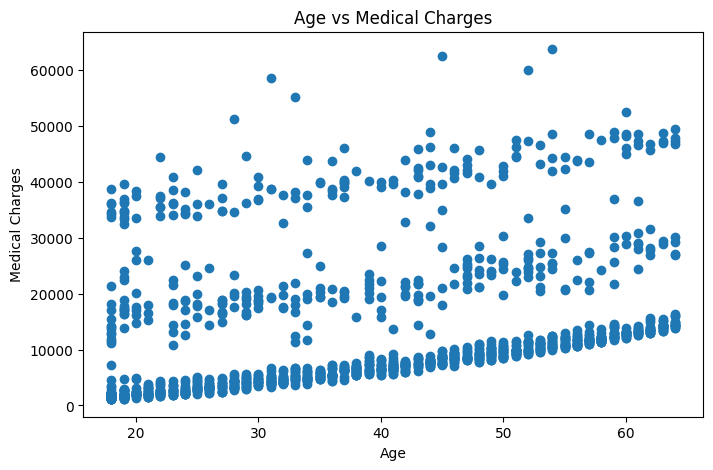

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(df['age'], df['charges'])
plt.xlabel('Age')
plt.ylabel('Medical Charges')
plt.title('Age vs Medical Charges')
plt.show()

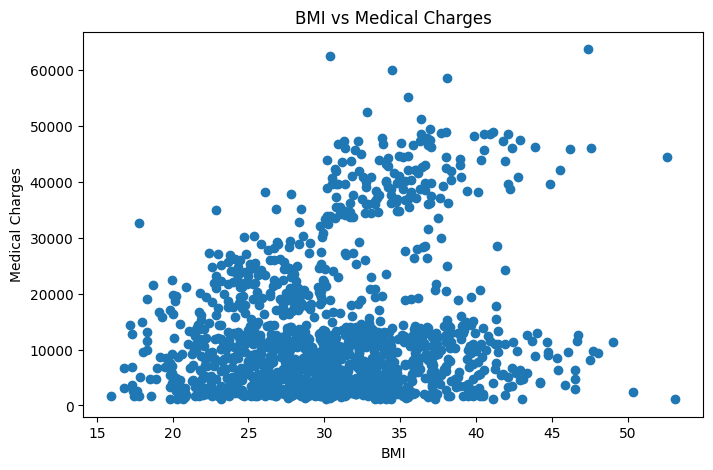

In [25]:
plt.figure(figsize=(8, 5))
plt.scatter(df['bmi'], df['charges'])
plt.xlabel('BMI')
plt.ylabel('Medical Charges')
plt.title('BMI vs Medical Charges')
plt.show()

<Figure size 800x500 with 0 Axes>

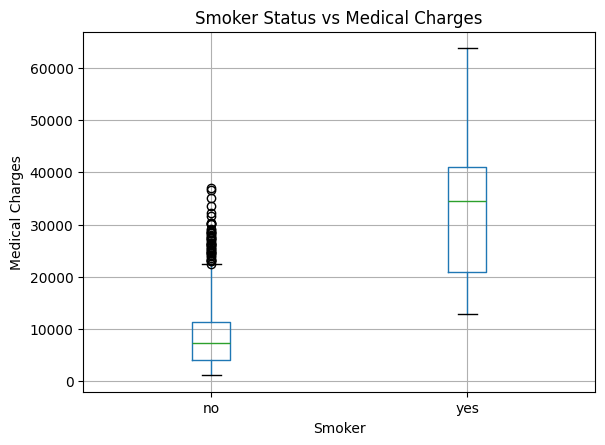

In [26]:
plt.figure(figsize=(8, 5))
df.boxplot(column='charges', by='smoker')
plt.xlabel('Smoker')
plt.ylabel('Medical Charges')
plt.title('Smoker Status vs Medical Charges')
plt.suptitle('')
plt.show()

###**2.Bagi dataset menjadi data latih (train) dan data uji (test) dengan proporsi yang sesuai.**

In [6]:
from sklearn.model_selection import train_test_split

Mengimpor train_test_split dari Scikit-Learn untuk membagi dataset menjadi data train dan data test.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

Membagi data menjadi 80% data train dan 20% data test. random_state=42 digunakan agar hasil pembagian data tetap sama setiap kali kode dijalankan.

In [8]:
print("Jumlah data train:", len(X_train))
print("Jumlah data test :", len(X_test))

Jumlah data train: 1070
Jumlah data test : 268


Menampilkan jumlah data yang digunakan untuk training dan testing.

###**3. Lakukan feature scaling jika diperlukan.**

In [9]:
from sklearn.preprocessing import StandardScaler

Mengimpor StandardScaler dari Scikit-Learn untuk melakukan standardisasi pada data.

In [10]:
X = pd.get_dummies(X, drop_first=True)

X.head()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,False,True,False,False,True
1,18,33.770,1,True,False,False,True,False
2,28,33.000,3,True,False,False,True,False
3,33,22.705,0,True,False,True,False,False
4,32,28.880,0,True,False,True,False,False


Mengubah variabel kategorikal seperti sex, smoker, dan region menjadi bentuk numerik agar dapat digunakan oleh model machine learning.

drop_first=True digunakan untuk menghindari variabel yang redundant.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

Membagi kembali data setelah proses encoding menjadi 80% data train dan 20% data test.

In [12]:
scaler_X = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

Melakukan standardisasi pada fitur training dan testing. fit_transform() digunakan pada data train, sedangkan data test hanya menggunakan transform() agar tidak terjadi kebocoran data.

In [13]:
scaler_y = StandardScaler()

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

Melakukan standardisasi pada target charges. Scaling target ini akan digunakan khususnya saat membangun model SVR.

###**4. Buat model multiple linear regression menggunakan Scikit-Learn.**

In [14]:
from sklearn.linear_model import LinearRegression

Mengimpor LinearRegression dari Scikit-Learn untuk membuat model regresi linear.

In [15]:
model_lr = LinearRegression()

Membuat objek model Multiple Linear Regression yang nantinya akan digunakan untuk proses training.

In [16]:
model_lr.fit(X_train, y_train)

LinearRegression()

Melatih model menggunakan data training agar model dapat mempelajari hubungan antara variabel fitur dengan biaya medis (charges).

In [17]:
y_pred_lr = model_lr.predict(X_test)

print(y_pred_lr[:10])

[ 8969.55027444  7068.74744287 36858.41091155  9454.67850053
 26973.17345656 10864.11316424   170.28084136 16903.45028662
  1092.43093614 11218.34318352]


Menggunakan model yang sudah dilatih untuk memprediksi biaya medis pada data testing. Sepuluh hasil prediksi pertama ditampilkan.

###**5. Latih model pada data latih dan lakukan prediksi pada data uji.**

In [31]:
y_pred_lr = model_lr.predict(X_test)

print(y_pred_lr[:10])

[ 8969.55027444  7068.74744287 36858.41091155  9454.67850053
 26973.17345656 10864.11316424   170.28084136 16903.45028662
  1092.43093614 11218.34318352]


Model yang sudah dilatih digunakan untuk memprediksi charges berdasarkan data X_test.

[:10] digunakan supaya hanya 10 hasil prediksi pertama yang ditampilkan.

###**6. Evaluasi model dengan menghitung metrik seperti R-squared, MSE, dan MAE. Tampilkan hasil evaluasi.**

In [32]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

Mengimpor fungsi yang digunakan untuk menghitung performa model.

In [33]:
r2_lr = r2_score(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print("R-squared :", r2_lr)
print("MSE       :", mse_lr)
print("MAE       :", mae_lr)

R-squared : 0.7835929767120724
MSE       : 33596915.85136145
MAE       : 4181.19447375365


###**7. Ulagi langkah 4 dengan menggunakan model SVR. Anda dapat bereksperimen dengan dengan melakukan hyperparameter tunning.**

In [27]:
model_svr = SVR(kernel='rbf')

Membuat model SVR menggunakan kernel RBF yang dapat digunakan untuk menangani hubungan non-linear antara fitur dan target.

In [28]:
model_svr.fit(X_train_scaled, y_train_scaled.ravel())

SVR()

Melatih model SVR menggunakan data fitur dan target yang sudah dilakukan feature scaling.

In [29]:
y_pred_svr_scaled = model_svr.predict(X_test_scaled)

y_pred_svr = scaler_y.inverse_transform(
    y_pred_svr_scaled.reshape(-1, 1)
).ravel()

print(y_pred_svr[:10])

[10102.94770606  6060.20005629 27774.19146969 10202.59361394
 24544.20250747  4897.24769808  3023.52620239 14963.84926197
  5153.03207952 11277.58071747]


Model digunakan untuk memprediksi biaya medis pada data test. Karena hasil prediksi masih dalam skala standar, inverse_transform() digunakan untuk mengembalikannya ke skala biaya medis asli.

In [34]:
r2_svr = r2_score(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)
mae_svr = mean_absolute_error(y_test, y_pred_svr)

print("R-squared :", r2_svr)
print("MSE       :", mse_svr)
print("MAE       :", mae_svr)

R-squared : 0.8622834992498352
MSE       : 21380312.04694896
MAE       : 2462.452729550437


Menghitung R², MSE, dan MAE untuk mengetahui performa model SVR.

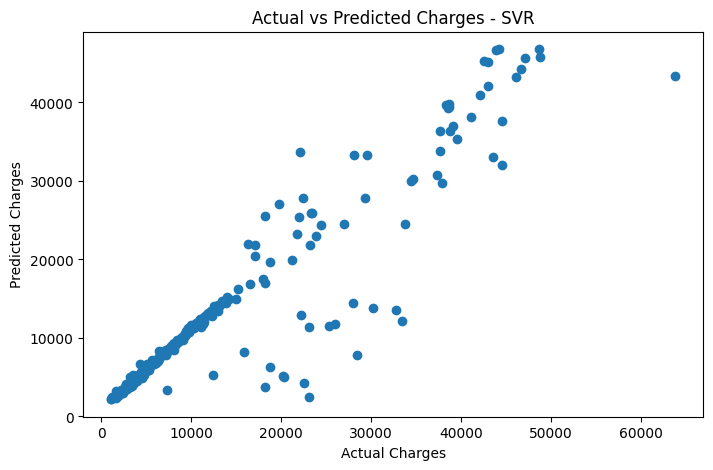

In [35]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_svr)
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs Predicted Charges - SVR')
plt.show()

Menampilkan perbandingan antara biaya medis sebenarnya dengan hasil prediksi SVR.

###Catatan

Berdasarkan hasil pengujian, model Multiple Linear Regression memperoleh nilai R-squared sebesar 0.7835929767120724 dengan nilai MSE 33596915.85136145 dan MAE 4181.19447375365 Sementara itu, model SVR memperoleh nilai R-squared sebesar 0.8622834992498352 dengan MSE 21380312.04694896 dan MAE 2462.452729550437 Perbedaan hasil tersebut menunjukkan bahwa kedua model memiliki performa yang berbeda dalam memprediksi biaya medis personal. Nilai R-squared, MSE, dan MAE digunakan sebagai dasar untuk melihat seberapa baik model dalam melakukan prediksi.